# Predicting Automation Risk Using a Neural Network

The goal here is to predict Automation Risk (%) for different job titles using the AI Job Automation dataset.

We attempt to train a fully connected neural network and analyze:

- Training behavior
- Validation performance
- Hyperparameter sensitivity
- Underfitting vs overfitting
- Feature relevance

The main objective is not just to train a model, but to understand whether the dataset actually contains predictive signal.

If performance is poor, we will investigate why and come up with another way to achieve our goal


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim

df = pd.read_csv("../../Datasets/ai_job_trends_dataset.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (30000, 13)


,Job Title,Industry,Job Status,AI Impact Level,Median Salary (USD),Required Education,Experience Required (Years),Job Openings (2024),Projected Openings (2030),Remote Work Ratio (%),Automation Risk (%),Location,Gender Diversity (%)
0,Investment analyst,IT,Increasing,Moderate,42109.76,Master’s Degree,5,1515,6342,55.96,28.28,UK,44.63
1,"Journalist, newspaper",Manufacturing,Increasing,Moderate,132298.57,Master’s Degree,15,1243,6205,16.81,89.71,USA,66.39
2,Financial planner,Finance,Increasing,Low,143279.19,Bachelor’s Degree,4,3338,1154,91.82,72.97,Canada,41.13
3,Legal secretary,Healthcare,Increasing,High,97576.13,Associate Degree,15,7173,4060,1.89,99.94,Australia,65.76
4,Aeronautical engineer,IT,Increasing,Low,60956.63,Master’s Degree,13,5944,7396,53.76,37.65,Germany,72.57


Before training any model, we should understand the target variable.

In [4]:
df["Automation Risk (%)"].describe()

count    30000.000000
mean        50.154229
std         28.754889
min          0.000000
25%         25.400000
50%         50.020000
75%         75.030000
max         99.990000
Name: Automation Risk (%), dtype: float64

We observe:

- Mean ≈ 50
- Standard deviation ≈ 28
- Values range from 0 to ~100

This means the target is continuous and fairly spread out.

Before jumping into deep learning, we should check if any feature actually correlates with the target.

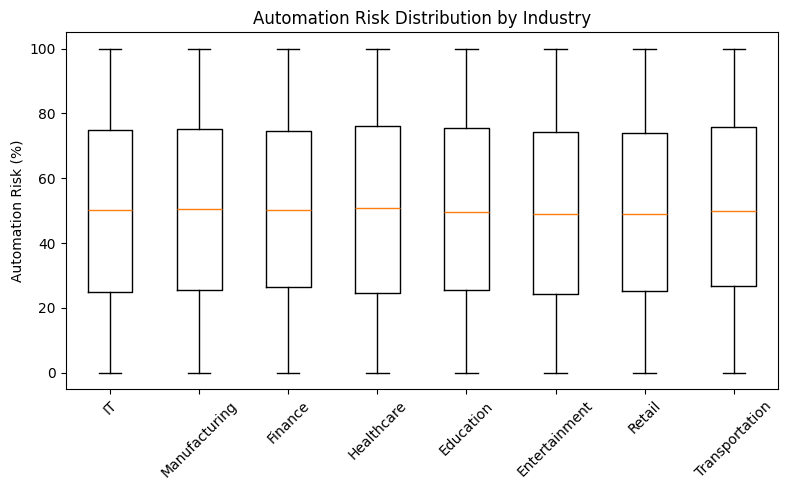

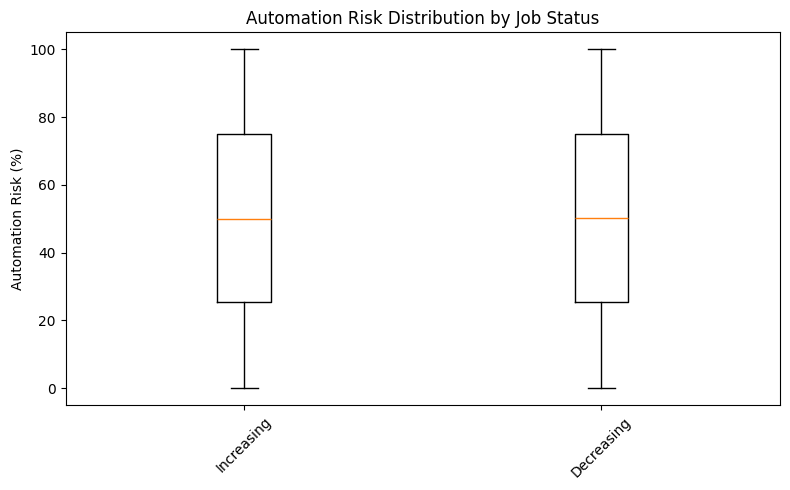

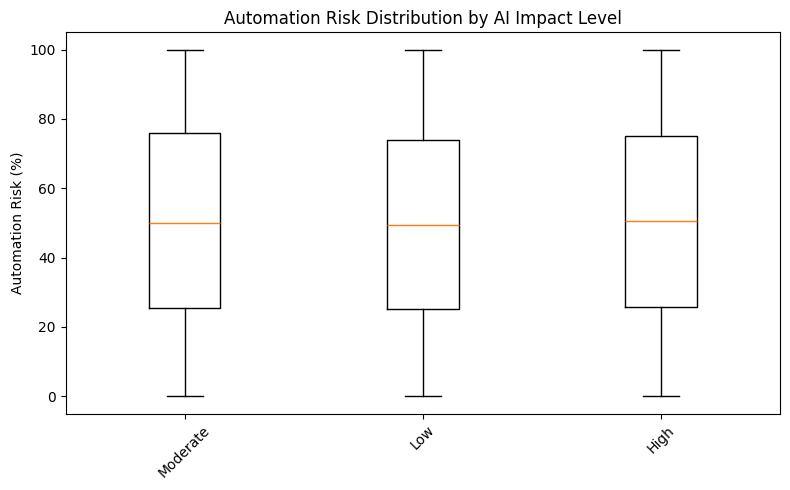

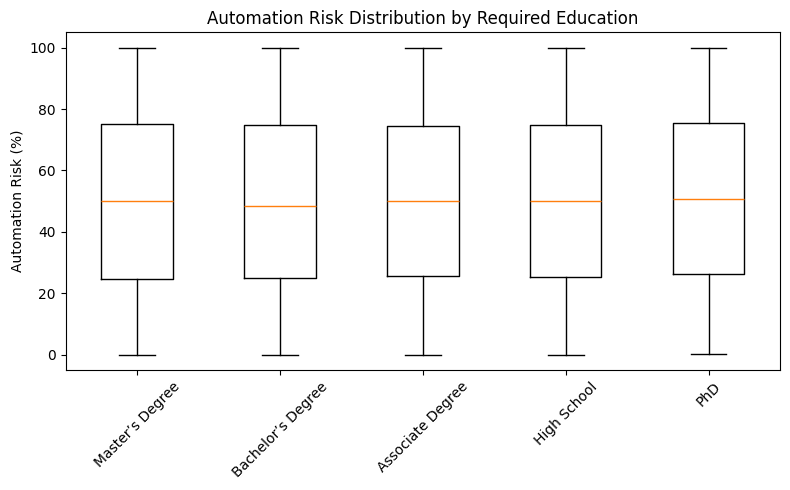

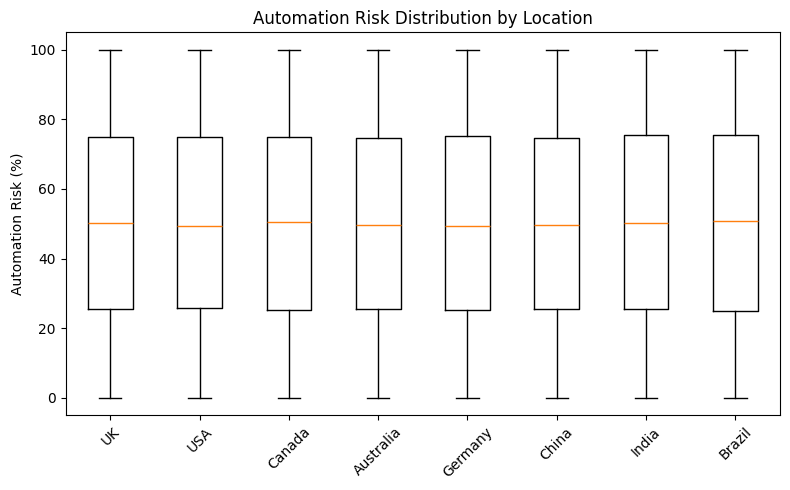

In [11]:
# This is for categorical variables

categorical_cols = ["Industry", "Job Status", "AI Impact Level", "Required Education", "Location"]

for col in categorical_cols:
    plt.figure(figsize=(8,5))
    
    groups = [group["Automation Risk (%)"].values 
              for name, group in df.groupby(col)]
    
    labels = df[col].unique()
    
    plt.boxplot(groups)
    plt.xticks(range(1, len(labels)+1), labels, rotation=45)
    plt.title(f"Automation Risk Distribution by {col}")
    plt.ylabel("Automation Risk (%)")
    plt.tight_layout()
    plt.show()


## Categorical Variable Analysis

We analyzed Industry, Job Status, AI Impact Level, Required Education, and Location using boxplots of Automation Risk (%).
If a categorical variable strongly affects automation risk, we would expect:

- Clearly different medians across categories
- Noticeable separation between groups
- Limited overlap in distributions

Instead, the medians across categories were very similar, mostly centered around the overall dataset mean (~50%). The spreads were large, and there was heavy overlap between groups.

This means that belonging to one category versus another does not systematically shift automation risk up or down. The variation inside each category is much larger than the variation between categories.

In short, these categorical variables do not show strong predictive signal for Automation Risk (%).

Automation Risk (%)            1.000000
Median Salary (USD)            0.007980
Projected Openings (2030)      0.007434
Experience Required (Years)    0.006541
Remote Work Ratio (%)          0.004851
Job Openings (2024)            0.003284
Gender Diversity (%)          -0.003737
JobTitleIdx                   -0.008947
Name: Automation Risk (%), dtype: float64


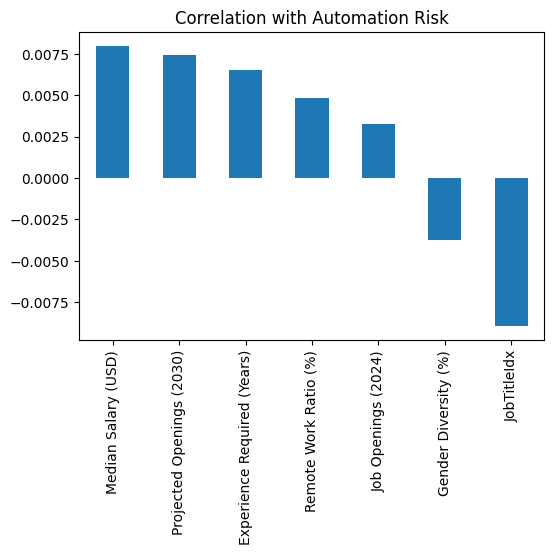

In [16]:
# This is for numerical variables

corr = df.corr(numeric_only=True)["Automation Risk (%)"].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(6,4))
corr.drop("Automation Risk (%)").plot(kind="bar")
plt.title("Correlation with Automation Risk")
plt.show()

## Numerical Variable Analysis

We then examined the numerical variables by computing their correlation with Automation Risk (%) and visualizing them in a bar plot. 
If a numerical variable is strongly related to automation risk, we would expect:

- A correlation value meaningfully different from 0 (positive or negative)
- A clear upward or downward relationship

However, the correlation values were all extremely close to zero. This indicates almost no linear relationship between these numerical features and Automation Risk (%).

In practical terms, this means changes in variables like salary, projected openings, experience required, etc., do not consistently correspond to increases or decreases in automation risk.

So, just like the categorical variables, the numerical variables also show very weak predictive signal for the target.

## Neural Network Experiment

After observing weak relationships in both categorical and numerical variables, we trained a neural network to confirm whether a nonlinear model could extract hidden structure.

In [33]:
X = df.drop("Automation Risk (%)", axis=1)
y = df["Automation Risk (%)"]

for col in X.select_dtypes(include=["object","string"]).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

model = nn.Sequential(
    nn.Linear(X_train.shape[1], 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(64, 1)
)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-3)


train_losses = []
test_losses = []
train_r2_scores = []
test_r2_scores = []
train_acc_scores = []
test_acc_scores = []

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        model.eval()
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test)

        train_losses.append(loss.item())
        test_losses.append(test_loss.item())

        train_r2 = r2_score(y_train.numpy(), outputs.numpy())
        test_r2 = r2_score(y_test.numpy(), test_outputs.numpy())

        train_r2_scores.append(train_r2)
        test_r2_scores.append(test_r2)

        train_acc = (torch.abs(outputs - y_train) <= 10).float().mean().item()
        test_acc = (torch.abs(test_outputs - y_test) <= 10).float().mean().item()

        train_acc_scores.append(train_acc)
        test_acc_scores.append(test_acc)

        print("Epoch:", epoch,
              "| Train R2:", train_r2,
              "| Test R2:", test_r2,
              "| Train Acc:", train_acc,
              "| Test Acc:", test_acc)


Epoch: 0 | Train R2: -3.048241138458252 | Test R2: -2.987028121948242 | Train Acc: 0.09383333474397659 | Test Acc: 0.10083333402872086
Epoch: 1 | Train R2: -3.037735939025879 | Test R2: -2.976369857788086 | Train Acc: 0.09466666728258133 | Test Acc: 0.1014999970793724
Epoch: 2 | Train R2: -3.026759624481201 | Test R2: -2.965451717376709 | Train Acc: 0.09579166769981384 | Test Acc: 0.10216666758060455
Epoch: 3 | Train R2: -3.0154294967651367 | Test R2: -2.954242467880249 | Train Acc: 0.09670833498239517 | Test Acc: 0.10316666960716248
Epoch: 4 | Train R2: -3.0040507316589355 | Test R2: -2.9427218437194824 | Train Acc: 0.09804166853427887 | Test Acc: 0.10483333468437195
Epoch: 5 | Train R2: -2.99261736869812 | Test R2: -2.9308464527130127 | Train Acc: 0.09858333319425583 | Test Acc: 0.10533333569765091
Epoch: 6 | Train R2: -2.9806325435638428 | Test R2: -2.918597936630249 | Train Acc: 0.09974999725818634 | Test Acc: 0.1068333312869072
Epoch: 7 | Train R2: -2.9682865142822266 | Test R2: -

### Why This Architecture?

We used a simple fully connected feed-forward neural network with two hidden layers:

- Input layer → 128 neurons
- Hidden layer → 64 neurons
- Output layer → 1 neuron (regression output)

We chose this architecture because:

The dataset is tabular, not image or sequential data. So a CNN or RNN would not be appropriate.

A multilayer perceptron (MLP) is the standard baseline model for structured tabular data. Two hidden layers allow the model to capture nonlinear relationships without being excessively deep. The output layer has one neuron because Automation Risk (%) is a continuous variable (regression task).

The goal was not to build an extremely complex model, but to use a reasonable nonlinear architecture to test whether meaningful patterns exist in the data.

### Adding Regularization

To make the experiment more rigorous, we added regularization to prevent overfitting.

Regularization helps prevent the model from memorizing noise in the training data.Dropout (0.3) randomly disables 30% of neurons during training.
This forces the model to learn more robust patterns instead of relying on specific neurons.

Weight decay (L2 penalty) discourages very large weights.
This prevents the model from becoming overly complex.

If the dataset contained strong predictive signal, we would expect:

- Training loss to decrease
- Validation loss to decrease
- R² to become meaningfully positive

However, even after adding regularization: Training and validation R² remain near zero

The model does not meaningfully outperform a baseline predictor

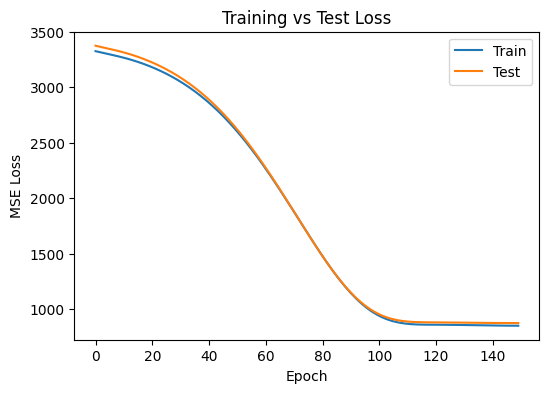

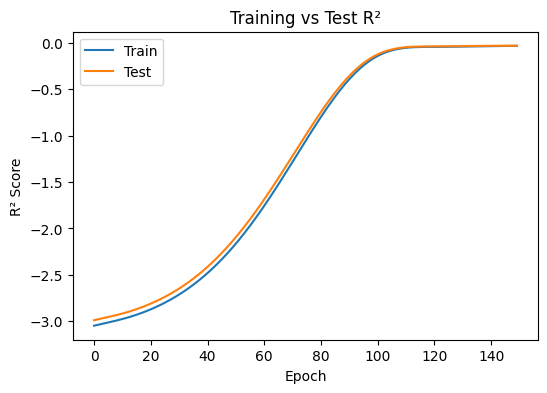

In [24]:
plt.figure(figsize=(6,4))
plt.plot(train_losses)
plt.plot(test_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend(["Train","Test"])
plt.title("Training vs Test Loss")
plt.show()
plt.figure(figsize=(6,4))
plt.plot(train_r2_scores)
plt.plot(test_r2_scores)
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.legend(["Train","Test"])
plt.title("Training vs Test R²")
plt.show()


## Interpretation of the Training Curves

From the loss curves, we observe that both training and testing loss decrease gradually over time. However, they quickly plateau and remain relatively high. There is no large gap between training and testing curves, which indicates that the model is not overfitting. Instead, both curves performing poorly suggests underfitting. The model is unable to capture meaningful structure in the data.

Looking at the R² curves, the scores remain close to zero (and sometimes negative) throughout training. A negative R² means the model performs worse than simply predicting the mean. Since both training and testing R² behave similarly, this further confirms that the issue is not overfitting but rather a lack of strong predictive signal in the features.

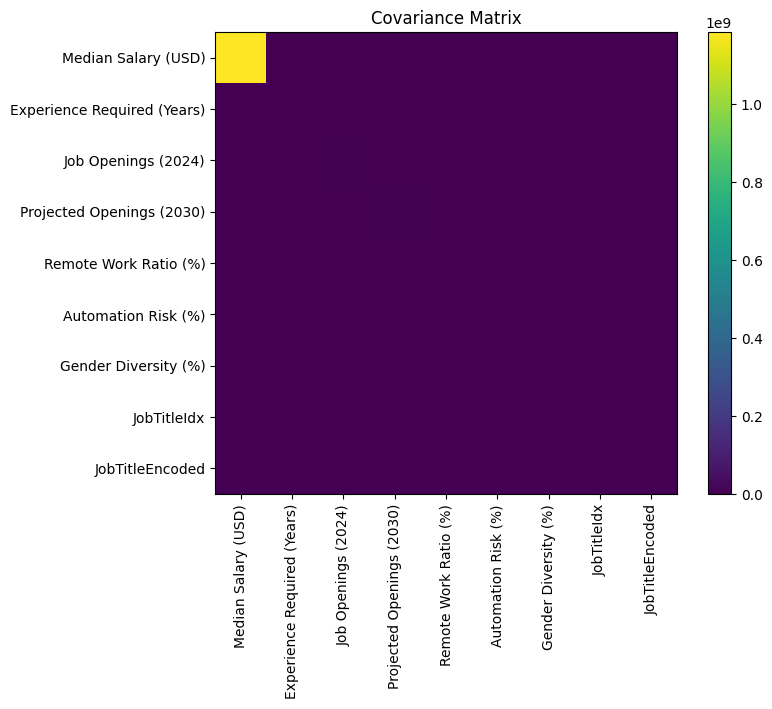

In [25]:
cov_matrix = df.cov(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(cov_matrix)
plt.colorbar()
plt.title("Covariance Matrix")
plt.xticks(range(len(cov_matrix.columns)), cov_matrix.columns, rotation=90)
plt.yticks(range(len(cov_matrix.columns)), cov_matrix.columns)
plt.show()


## Interpretation of the Covariance Matrix

The covariance (and correlation) analysis shows that most features have values very close to zero with respect to Automation Risk. This means that changes in these variables do not consistently move together with changes in automation risk.

If strong predictive relationships existed, we would expect to see noticeably larger covariance or correlation values. Instead, the matrix suggests that the features are largely independent from the target variable. This aligns with the neural network results: the model struggles not because of architecture or regularization choices, but because the input variables themselves do not meaningfully explain variation in automation risk.

## Visualization of Top and Bottom 20 Job Titles

To better understand whether automation risk varies meaningfully across job roles, we compute the mean Automation Risk (%) for each Job Title and visualized the top 20 highest and lowest averages.

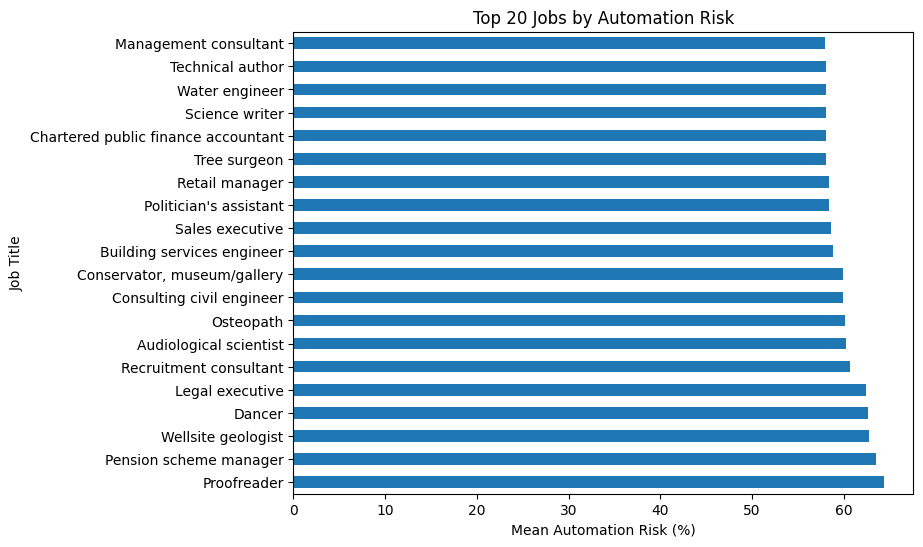

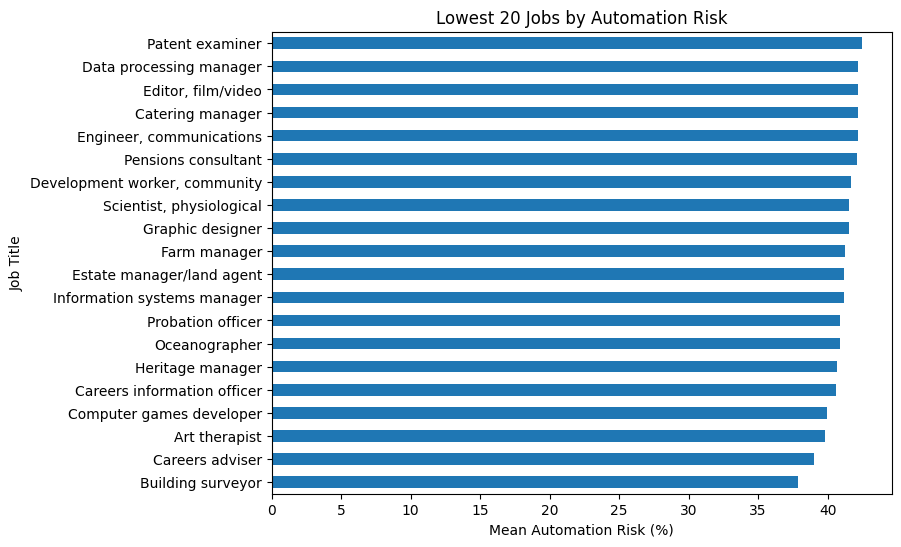

In [14]:
job_means = df.groupby("Job Title")["Automation Risk (%)"].mean()

top_20 = job_means.sort_values(ascending=False).head(20)
bottom_20 = job_means.sort_values().head(20)

plt.figure(figsize=(8,6))
top_20.plot(kind="barh")
plt.title("Top 20 Jobs by Automation Risk")
plt.xlabel("Mean Automation Risk (%)")
plt.show()

plt.figure(figsize=(8,6))
bottom_20.plot(kind="barh")
plt.title("Lowest 20 Jobs by Automation Risk")
plt.xlabel("Mean Automation Risk (%)")
plt.show()


### Explanation

The bar charts clearly show that some job titles have much higher average automation risk than others. The top 20 jobs cluster toward very high automation percentages, while the bottom 20 cluster near very low values. This confirms that automation risk is not uniformly distributed across job titles.

However, although the averages differ across jobs, this does not necessarily mean the relationship is clean or predictable. Earlier analysis showed that within many job titles, there is still large variation in automation risk. So while job title appears to influence the mean level, the spread within each group weakens its predictive strength.

Overall, this visualization suggests that job title is the strongest structural signal in the dataset, but it is still not sufficient on its own to allow accurate prediction of automation risk.

## Overall Conclusion

After analyzing both categorical and numerical variables, we found that most features show very weak correlation with Automation Risk (%). Boxplots of categorical variables revealed heavy overlap and similar medians across categories, indicating little separation between groups. Numerical correlation values were also close to zero, suggesting almost no linear relationship with the target.

We then trained a neural network with regularization (dropout and weight decay) to test whether nonlinear structure could be extracted from the data. However, both training and test R² scores remained close to zero, and accuracy (within ±10 percentage points) remained relatively low. The training and validation curves followed similar patterns, indicating underfitting rather than overfitting. This confirms that the issue is not model complexity but rather a lack of strong predictive signal in the dataset.

Although visualizing the top and bottom 20 job titles showed differences in average automation risk, the large variance within job titles weakens the ability of supervised models to learn stable mappings.

Given these findings, we conclude that traditional deep learning models are not effective for predicting automation risk using the provided structured features.

## What Will We Do Instead?

Instead, we propose shifting to a language model–based approach. Specifically, we will use an OpenAI LLM to estimate automation risk by providing:

- The job title
- Contextual information (industry, AI impact level, etc.)
- The automation risk scores available in this dataset
- The skill-level assessments obtained from the O*NET analysis

By leveraging semantic reasoning over job descriptions and skill requirements, an LLM may better capture the conceptual factors that drive automation risk, which structured numerical features in this dataset fail to represent adequately.